# 3HDM with S₃ flavor symmetry: forcing the vacuum, not tuning it

A generic three-Higgs-doublet potential has dozens of independent quartic
couplings — far too many to be predictive. One standard way to cut that
down is to impose a **discrete flavor symmetry** on the scalar sector: pick
a finite group, assign the doublets to its representations, and keep only
the quartic invariants that group theory allows.

This notebook builds the simplest non-abelian example: $S_3$, the
permutation group on 3 objects, with $(H_1, H_2)$ forming its 2-dimensional
irrep and a third doublet $H_S$ sitting in the trivial singlet. It follows
`examples/thdm_s3.py` step by step, showing two things no earlier feynlag
tutorial needed:

1. **Finite discrete-symmetry invariance.** Every gauge check in prior
   tutorials linearizes the transformation at $\alpha=0$ (a continuous Lie
   group). $S_3$ has no such infinitesimal neighborhood of the identity —
   `feynlag` instead applies the group's *exact, finite* substitution and
   checks the Lagrangian term-by-term for literal equality.
2. **A vacuum that isn't free to choose.** With three VEVs ($v_1, v_2,
   v_S$) but an $S_3$-covariant potential that only has *two* independent
   mass parameters ($\mu_0^2,\mu_1^2$) to absorb tadpole conditions, the
   third condition becomes a real constraint. Solving it doesn't tune a
   free ratio — it **forces** $v_1/v_2$ to a fixed value.

Along the way we also see the $S_3$ Clebsch–Gordan decomposition
$2\otimes2 = 1\oplus1'\oplus2$ that the potential is built from, and the
resulting $3\times3$ CP-even scalar mass matrix.

## 1. Symmetries, parameters, fields

$S_3$ has three irreducible representations:

- $\mathbf{1}$ — trivial: every group element acts as $+1$.
- $\mathbf{1'}$ — the sign representation: the 3-cycle acts as $+1$, the
  transposition as $-1$.
- $\mathbf{2}$ — a genuine 2-dimensional (real, orthogonal) doublet:
  `feynlag`'s `S3` represents the 3-cycle generator as a $2\pi/3$ rotation
  matrix and the transposition generator as a reflection
  $\mathrm{diag}(1,-1)$.

`s3.assign(irrep, *fields)` below registers which fields sit in which
irrep and builds, from those generator matrices, an explicit finite
substitution map (one linear combination of components per group
generator) — this is what `check_discrete_invariance` later applies
*exactly*, in contrast to the $O(\alpha)$ linearized check every gauge
symmetry in this library uses.

We also declare the usual electroweak gauge sector ($SU(2)_L\times U(1)_Y$)
alongside $S_3$ — the potential must satisfy *both* symmetries at once.

In [ ]:
import sympy as sp
from IPython.display import display
sp.init_printing()

from feynlag import (
    ExternalParameter, InternalParameter, Lagrangian, Model, S3, SU2,
    Scalar, U1, check_discrete_invariance, dag,
)

gw = ExternalParameter("gw", 0.6535, positive=True)
g1 = ExternalParameter("g1", 0.3580, positive=True)
SU2L, U1Y = SU2("SU2L", coupling=gw), U1("U1Y", coupling=g1)
s3 = S3()

v1 = ExternalParameter("v1", 200.0, positive=True, unit_dim=1)
v2 = ExternalParameter("v2", 115.0, positive=True, unit_dim=1)
vS = ExternalParameter("vS", 80.0, positive=True, unit_dim=1)
lams = {k: ExternalParameter(f"lm{k}", 0.05 * k) for k in range(1, 9)}
mu0sq = InternalParameter("mu0sq", unit_dim=2)
mu1sq = InternalParameter("mu1sq", unit_dim=2)

Before wiring up real fields, let's see the $2\otimes2$
Clebsch–Gordan decomposition on abstract symbols — `S3.doublet_product`
returns the three channels the tensor product of two doublets splits
into.

In [ ]:
a1, a2, b1, b2 = sp.symbols("a1 a2 b1 b2")
cg = s3.doublet_product((a1, a2), (b1, b2))
cg

{'1': a1*b1 + a2*b2, '1p': a1*b2 - a2*b1, '2': (a1*b1 - a2*b2, -a1*b2 - a2*b1)}

So $2\otimes2 = 1\oplus1'\oplus2$: a singlet ($a_1b_1+a_2b_2$), a
pseudo-singlet ($a_1b_2-a_2b_1$), and — since a doublet's tensor square
must contain another doublet — a second copy of the **2** itself. We'll
reuse these exact three combinations below, applied not to raw field
components but to the gauge-invariant bilinears $H_i^\dagger H_j$.

## 2. Building the $S_3$-covariant potential from Clebsch–Gordan invariants

$H_1, H_2, H_S$ are three ordinary $SU(2)_L\times U(1)_Y$ Higgs doublets.
`s3.assign("2", H1, H2)` puts $(H_1,H_2)$ in the doublet irrep;
`s3.assign("1", HS)` puts $H_S$ in the trivial singlet.

In [ ]:
def doublet(name):
    return Scalar(name, reps={SU2L: 2, U1Y: sp.Rational(1, 2)},
                  component_names=[f"{name}p", f"{name}0"])

H1, H2, HS = doublet("H1"), doublet("H2"), doublet("HS")
s3.assign("2", H1, H2)
s3.assign("1", HS)

H1.expand_vev({H1.components[1]: v1})
H2.expand_vev({H2.components[1]: v2})
HS.expand_vev({HS.components[1]: vS})

Scalar('HS')

`bra(a, b)` builds the $SU(2)_L\times U(1)_Y$-invariant bilinear
$a^\dagger b$. The doublet-index CG formulas from above apply directly to
these bilinears, with $(a_1,a_2)=(H_1^\dagger,H_2^\dagger)$ on the bra side
and $(b_1,b_2)=(H_1,H_2)$ on the ket side: $a_1b_1\to H_1^\dagger H_1$,
$a_1b_2\to H_1^\dagger H_2$, and so on.

In [ ]:
def bra(a, b):
    return (dag(a) * b.mat)[0]

x11, x22 = bra(H1, H1), bra(H2, H2)
x12, x21 = bra(H1, H2), bra(H2, H1)
s1, s2 = bra(HS, H1), bra(HS, H2)
sss = bra(HS, HS)

inv1 = x11 + x22          # the '1' channel:  a1*b1 + a2*b2
inv1p = x12 - x21         # the '1\'' channel: a1*b2 - a2*b1
d2 = (x11 - x22, -(x12 + x21))   # the '2' channel

display(inv1)
display(inv1p)
display(d2)

$H_S$ enters the potential through its own doublet of bilinears,
$(s_1,s_2)=(H_S^\dagger H_1,\,H_S^\dagger H_2)$, which transforms exactly
like $(H_1,H_2)$ under $S_3$. Contracting this doublet with itself, or
with the $(H_1,H_2)$ doublet channel `d2`, gives two more singlet
invariants — both need an explicit $+\text{h.c.}$ since neither
combination is manifestly real on its own.

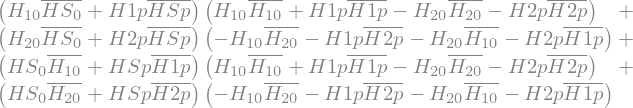

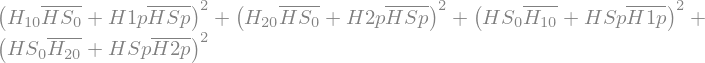

In [ ]:
lam4_term = s1 * d2[0] + s2 * d2[1]
lam4_term += sp.conjugate(lam4_term)     # (HS†H)_2 ⊗ (H†H)_2 → 1, + h.c.

lam7_term = s1**2 + s2**2
lam7_term += sp.conjugate(lam7_term)     # (HS†H)_2 ⊗ (HS†H)_2 → 1, + h.c.

display(lam4_term)
display(lam7_term)

All 8 quartic couplings are now S₃-invariant combinations built from
`inv1`, `inv1p`, `d2`, `lam4_term`, `lam7_term`, `sss`:

| Coupling | CG channel | Term | Role |
|---|---|---|---|
| $\lambda_1$ | $1\otimes1$ | $(H_1^\dagger H_1+H_2^\dagger H_2)^2$ | ordinary doublet-sector quartic |
| $\lambda_2$ | $1'\otimes1'$ | $(H_1^\dagger H_2-H_2^\dagger H_1)^2$ | pseudo-singlet quartic |
| $\lambda_3$ | $2\otimes2\to1$ | $d_2\cdot d_2$ | doublet-channel self-contraction |
| $\lambda_4$ | $(H_S^\dagger H)_2\otimes(H^\dagger H)_2\to1$, + h.c. | $s\cdot d_2$ + h.c. | singlet–doublet mixed quartic |
| $\lambda_5$ | $1\otimes1$ | $(H_S^\dagger H_S)(H_1^\dagger H_1+H_2^\dagger H_2)$ | portal-like singlet×doublet-norm coupling |
| $\lambda_6$ | $2\otimes\bar2\to1$ | $s_1(H_1^\dagger H_S)+s_2(H_2^\dagger H_S)$ | $|s_1|^2+|s_2|^2$-type cross term |
| $\lambda_7$ | $(H_S^\dagger H)_2\otimes(H_S^\dagger H)_2\to1$, + h.c. | $s_1^2+s_2^2$ + h.c. | CP-sensitive; needs + h.c. to be Hermitian |
| $\lambda_8$ | $1\otimes1$ | $(H_S^\dagger H_S)^2$ | pure singlet quartic |

plus a mass term for each $S_3$ singlet sector, $\mu_1^2(H_1^\dagger
H_1+H_2^\dagger H_2)$ and $\mu_0^2 H_S^\dagger H_S$.

In [ ]:
l = {k: p.s for k, p in lams.items()}
V = (mu1sq.s * inv1 + mu0sq.s * sss
     + l[1] * inv1**2 + l[2] * inv1p**2
     + l[3] * (d2[0]**2 + d2[1]**2)
     + l[4] * lam4_term
     + l[5] * sss * inv1
     + l[6] * (s1 * bra(H1, HS) + s2 * bra(H2, HS))
     + l[7] * lam7_term
     + l[8] * sss**2)

L = Lagrangian().add(-V, sector="potential")

## 3. Assemble the model and check invariance

Everything above was built from gauge-invariant bilinears and $S_3$
Clebsch–Gordan combinations by hand — but nothing has actually *verified*
gauge or $S_3$ invariance yet. `Model.check_invariance()` checks every
term against both `gauge_groups` and `discrete_groups` at once.

In [ ]:
model = Model("3HDM-S3", gauge_groups=[SU2L, U1Y], discrete_groups=[s3],
              fields=[H1, H2, HS],
              parameters=[gw, g1, v1, v2, vS, mu0sq, mu1sq,
                          *lams.values()],
              lagrangian=L)

report = model.check_invariance()
print("invariant:", report.ok)
if not report.ok:
    print(report.failures)

invariant: True


What if a term *weren't* $S_3$-invariant? Take, for instance,
$(H_S^\dagger H_1)(H_1^\dagger H_1) + \text{h.c.}$ — it singles out $H_1$
without pairing it with the matching $H_2$ combination the doublet
structure requires. `check_discrete_invariance` catches this directly,
without needing a full `Model`.

In [ ]:
bad = (dag(HS) * H1.mat)[0] * (dag(H1) * H1.mat)[0]
bad = bad + sp.conjugate(bad)

ok, _ = check_discrete_invariance(bad, s3)
print("forbidden term is S3-invariant?", ok)

forbidden term is S3-invariant? False


## 4. Tadpoles and the forced $\sqrt3$ vacuum alignment

There are three VEVs ($v_1,v_2,v_S$) but the $S_3$-covariant potential
only has **two** independent mass parameters ($\mu_0^2,\mu_1^2$) free to
absorb tadpole conditions. Solving the $v_2$ and $v_S$ conditions for
$\mu_0^2,\mu_1^2$ and substituting into the $v_1$ condition therefore
leaves a genuine constraint on $v_1,v_2$ alone — not an identity.

residual v1-tadpole condition:


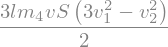

In [ ]:
tadpoles = model.tadpoles()
t1, t2, tS = tadpoles[v1.s], tadpoles[v2.s], tadpoles[vS.s]

sol = sp.solve([sp.Eq(t2, 0), sp.Eq(tS, 0)], [mu0sq.s, mu1sq.s], dict=True)[0]
residual = sp.factor(sp.expand(t1.subs(sol)))
print("residual v1-tadpole condition:")
display(residual)

The residual factors as $\propto v_S(3v_1^2 - v_2^2)$: since
$v_S\neq0$, the only way to satisfy all three tadpole conditions
simultaneously is $v_1^2 = v_2^2/3$ — a fixed ratio, not a free parameter.
(`docs/manual/ssb.md` frames this as a structural consequence of the CG
structure, not a coincidence of the numeric benchmark point; the
`declaration.md` chapter notes that `feynlag`'s real-orthogonal $S_3$
basis swaps which doublet component the literature's $v_1=\sqrt3\,v_2$
convention refers to — the ratio *squared* is the basis-independent
statement.)

In [ ]:
v1_solutions = sp.solve(sp.Eq(residual, 0), v1.s)
print("v1 solutions:", v1_solutions)
for s_v1 in v1_solutions:
    ratio_sq = sp.simplify((s_v1 / v2.s) ** 2)
    print("  (v1/v2)^2 =", ratio_sq)

v1 solutions: [sqrt(3)*v2/3]
  (v1/v2)^2 = 1/3


## 5. CP-even mass matrix on the aligned vacuum

Imposing the alignment and re-solving the two mass parameters
consistently, the $v_1$ tadpole condition is now automatically satisfied
— confirming the alignment is exactly what's needed, not an
approximation.

In [ ]:
align = {v1.s: v2.s / sp.sqrt(3)}

sol2 = sp.solve([sp.Eq(tadpoles[v2.s].subs(align), 0),
                 sp.Eq(tadpoles[vS.s].subs(align), 0)],
                [mu0sq.s, mu1sq.s], dict=True)[0]

print("v1 tadpole after alignment + resolving mu0sq, mu1sq:",
      sp.simplify(tadpoles[v1.s].subs(align).subs(sol2)))

v1 tadpole after alignment + resolving mu0sq, mu1sq: 0


`Model.mass_matrix` takes the real CP-even fluctuations
(`expand_vev`'s auto-generated `{name}0_r` symbols) and returns
$\partial^2V/\partial\phi_i\partial\phi_j$ evaluated on the vacuum, with
any cached tadpole solutions applied automatically.

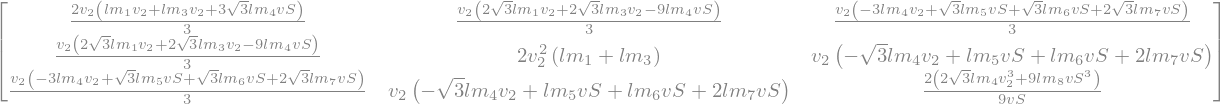

In [ ]:
h = [sp.Symbol(f"{n}0_r", real=True) for n in ("H1", "H2", "HS")]
M = model.mass_matrix(h).subs(sol2).subs(align)
M = M.applyfunc(lambda e: sp.simplify(sp.expand(e)))
M

In [ ]:
print("symmetric:", sp.simplify(M - M.T) == sp.zeros(3, 3))
print("nonzero diagonal:", M[0, 0] != 0 and M[1, 1] != 0 and M[2, 2] != 0)

symmetric: True
nonzero diagonal: True


## 6. Recap

| Step | Tool | Result |
|---|---|---|
| Declare $S_3$ irreps + gauge groups | `S3`, `SU2`, `U1`, `s3.assign` | $(H_1,H_2)$ in the **2**, $H_S$ in the **1** |
| Build the potential from CG invariants | `S3.doublet_product`, `bra` | 8 $S_3$-covariant quartics, matching the abstract $1\oplus1'\oplus2$ split |
| Check both symmetries at once | `Model.check_invariance` | gauge **and** finite $S_3$ invariance both pass |
| Catch a broken term | `check_discrete_invariance` | a term missing its $H_2$ partner is rejected |
| Solve the tadpoles | `Model.tadpoles`, `sp.solve` | 3 VEVs, 2 free mass parameters → $v_1^2=v_2^2/3$ forced |
| Diagonalizable mass sector | `Model.mass_matrix` | symmetric $3\times3$ CP-even matrix on the aligned vacuum |

The headline result: a discrete flavor symmetry doesn't just forbid
individual couplings — an over-constrained potential can force the vacuum
itself onto a specific, symmetry-preserving direction, derived here
directly from the symbolic tadpole system rather than assumed.

**Where to go next:**

- `SUN_Groups_Tutorial.ipynb` — a deeper dive into representation theory,
  for continuous gauge groups.
- `docs/manual/declaration.md` — how `S3`'s real-orthogonal generators are
  chosen, and `S3.doublet_product`.
- `docs/manual/ssb.md` — the general tadpole-solving machinery and this
  exact worked case.
- `docs/manual/invariance.md` — the finite vs. infinitesimal invariance
  check, and why the fermion bar-leg transform differs between $S_3$ and
  $Z_N$.